In [2]:
import numpy as np
from numpy.typing import NDArray
from matplotlib import pyplot as plt
import math
from sklearn.linear_model import LinearRegression

In [3]:


def sieve_of_eratosthenes_numpy(limit):
    """
    Generates primes up to a given limit using the Sieve of Eratosthenes with NumPy.
    """
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[0:2] = False  # 0 and 1 are not prime

    for p in range(2, int(np.sqrt(limit)) + 1):
        if is_prime[p]:
            is_prime[p*p::p] = False  # Mark multiples of p as not prime

    primes = np.where(is_prime)[0]
    return primes

# To get the first one million primes, the limit needs to be appropriately set.
# The millionth prime is 15,485,863.
limit_for_million_primes = 15485863
limit_for_10_million_primes = 99999991
limit_for_100_million_primes = 999999989

# Generate primes up to the limit
all_primes_up_to_limit = sieve_of_eratosthenes_numpy(limit_for_100_million_primes)

# Extract the first one million primes
first_million_primes = all_primes_up_to_limit

print(f"Number of primes found: {len(first_million_primes)}")
# print(first_million_primes) # Uncomment to print the list of primes

Number of primes found: 50847534


In [4]:
delta_prime_set: NDArray = np.array([first_million_primes[i+1] - first_million_primes[i] for i in range(len(first_million_primes)-1)])
print(f"Delta prime set (first 10 values): {delta_prime_set[:10]}")

Delta prime set (first 10 values): [1 2 2 4 2 4 2 4 6 2]


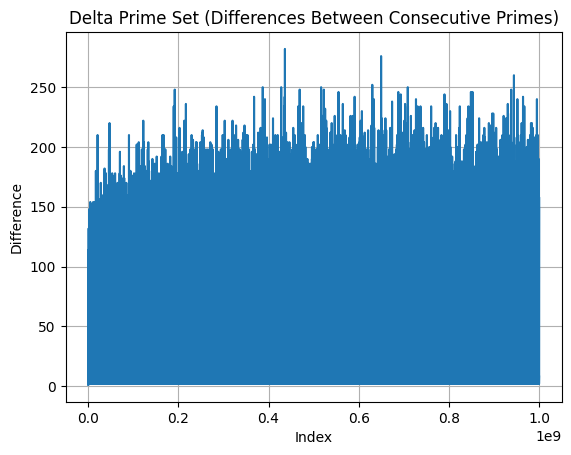

In [5]:
plt.plot(first_million_primes[:-1],delta_prime_set)
plt.title("Delta Prime Set (Differences Between Consecutive Primes)")
plt.xlabel("Index")
plt.ylabel("Difference")
plt.grid()
plt.show()

Mean of delta prime set: 19.666636235822885
Median of delta prime set: 14.0
Standard deviation of delta prime set: 17.06660687691458
Max of delta prime set: 282
Min of delta prime set: 1
Mean - Median: 5.666636235822885


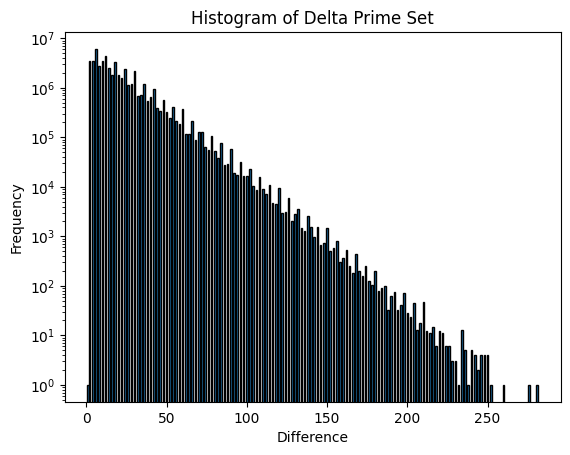

In [6]:
analysis_set = delta_prime_set
print("Mean of delta prime set:", np.mean(analysis_set))
print("Median of delta prime set:", np.median(analysis_set))
print("Standard deviation of delta prime set:", np.std(analysis_set))
print("Max of delta prime set:", np.max(analysis_set))
print("Min of delta prime set:", np.min(analysis_set))
print("Mean - Median:", np.mean(analysis_set) - np.median(analysis_set))
# Histogram of delta prime set
plt.hist(analysis_set, bins=range(1, np.max(analysis_set)+1), edgecolor='black', align='left')
plt.title("Histogram of Delta Prime Set")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.yscale('log')  # Use logarithmic scale for better visibility
plt.show()

In [7]:
np.histogram(analysis_set, bins=range(1, np.max(analysis_set)+1), density=True)
print("Histogram bins and densities calculated.")
X = np.log(np.array([[i] for i in range(1, len(analysis_set)+1)]))
y = np.log(analysis_set)
print("Prepared log-transformed data for linear regression.")
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

Histogram bins and densities calculated.
Prepared log-transformed data for linear regression.


/workspaces/ros2-coding/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


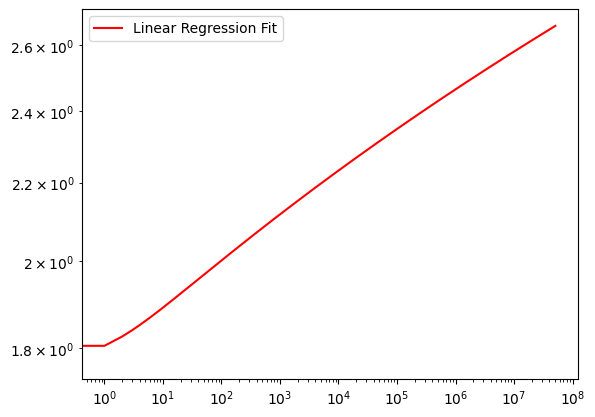

In [8]:
plt.plot(y_pred, color='red', label='Linear Regression Fit')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

Residual analysis: [-1.7700154  -1.11169659 -1.13206988 ... -0.35902514  0.9219087
 -0.58216869]


Text(0, 0.5, 'Frequency')

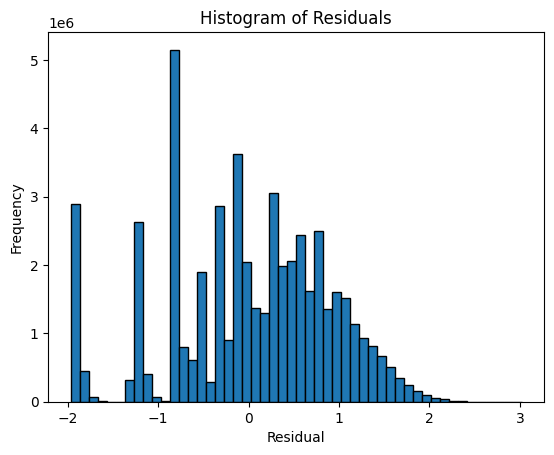

In [9]:
residuals = y - y_pred.flatten()
print("Residual analysis:", residuals)
plt.hist(residuals, bins=50, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

In [10]:
print("Mean of residuals:", np.mean(residuals))
print("Median of residuals:", np.median(residuals))
print("Standard deviation of residuals:", np.std(residuals))

Mean of residuals: 3.564462098275429e-16
Median of residuals: 0.05238401174455953
Standard deviation of residuals: 0.9065107771395127


In [11]:
print(model.coef_, model.intercept_)
print("Equation of the fitted line: log(y) = {:.4f} * log(x) + {:.4f}".format(model.coef_[0], model.intercept_))

[0.05024671] 1.7700154017456275
Equation of the fitted line: log(y) = 0.0502 * log(x) + 1.7700


In [ ]:
# prime_sums_limited: NDArray = np.array([])
# for x in range(len(analysis_set)):
#     sum = prime_sums_limited[-1] + analysis_set[x] if x > 0 else analysis_set[0]
#     print(x)
#     prime_sums_limited = np.append(prime_sums_limited, sum)
np.cumsum(analysis_set)
prime_sums_limited: NDArray = np.cumsum(analysis_set)
print("Cumulative sums of delta prime set calculated.")

Cumulative sums of delta prime set calculated.


: 

In [ ]:
plt.plot(prime_sums_limited)